In [56]:
import numpy as np 
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import random

### codice per caso con tre porte

In [59]:
n = 3 # numero di porte 
n_sim = 10000  # numero di simulazioni

#numero dei contatori
n_switch = 0
n_conservative = 0
n_last_arrival = 0 

for i in range(n_sim): 
    
    doors = np.array(["g"] * n)
    index = np.arange(n)
    c_index = np.random.choice(index) #indice della macchina 
    doors[c_index] = "c" # "rinomino" con c indice scelto 
    choosen_door_index = np.random.choice(index)
    
    # porte che Monty può aprire (quelle con le capre) 
    g_doors_index = []
    for j in index:
        if j != choosen_door_index and doors[j] == "g":
            g_doors_index.append(j)
    
    # Monty apre una porta
    monty_opens_index = None
    if g_doors_index: #significa che è definita 
        monty_opens_index = np.random.choice(g_doors_index)
    
    switch_choice_index = None
    last_arrival_choise_index = None
    
    for k in index:
        if k != monty_opens_index:
            last_arrival_choise_index = k
            if k != choosen_door_index:
                switch_choice_index = k
    

    if doors[switch_choice_index] == "c":
        n_switch += 1
    
    if doors[last_arrival_choise_index] == "c":
        n_last_arrival += 1

    if doors[choosen_door_index] == "c":
        n_conservative += 1

# probabilità stimate
p_switch = n_switch / n_sim
p_last_arrival = n_last_arrival / n_sim
p_conservative = n_conservative / n_sim

print("Probabilità vincita cambiando porta:", p_switch)
print("Probabilità ultimo arrivato:", p_last_arrival)
print("Probabilità vincita restando:", p_conservative)

Probabilità vincita cambiando porta: 0.6693
Probabilità ultimo arrivato: 0.5049
Probabilità vincita restando: 0.3307


([<matplotlib.axis.XTick at 0x19548aefc20>,
 [Text(0, 0, 'switch'),
  Text(1, 0, 'last arrival'),
  Text(2, 0, 'conservative')])

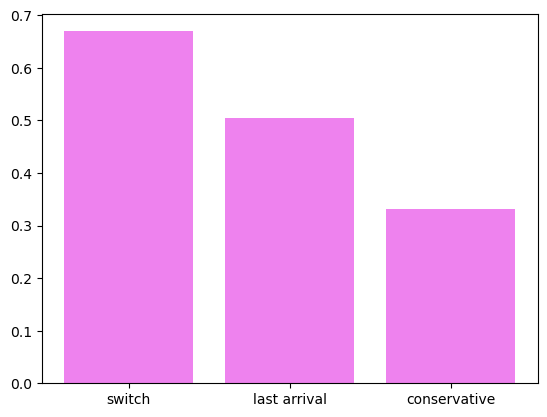

In [61]:
plt.bar([0,1,2], [p_switch, p_last_arrival, p_conservative], color='violet')
plt.xticks([0,1,2], ["switch", "last arrival", "conservative"])

In [63]:
#numero dei contatori
n_switch = 0
n_conservative = 0
n_last_arrival = 0 

steps = []
probs_switch = []
probs_last = []
probs_conservative = []

for i in tqdm(range(1, 1000 + 1)):
    
    doors = np.array(["g"] * n)
    index = np.arange(n)
    c_index = np.random.choice(index) #indice della macchina 
    doors[c_index] = "c" # "rinomino" con c indice scelto 
    choosen_door_index = np.random.choice(index)
    
    # porte che Monty può aprire (quelle con le capre) 
    g_doors_index = []
    for j in index:
        if j != choosen_door_index and doors[j] == "g":
            g_doors_index.append(j)
    
    # Monty apre una porta
    monty_opens_index = None
    if g_doors_index: #significa che è definita 
        monty_opens_index = np.random.choice(g_doors_index)
    
    switch_choice_index = None
    last_arrival_choise_index = None
    
    for k in index:
        if k != monty_opens_index:
            last_arrival_choise_index = k
            if k != choosen_door_index:
                switch_choice_index = k
    

    if doors[switch_choice_index] == "c":
        n_switch += 1
    
    if doors[last_arrival_choise_index] == "c":
        n_last_arrival += 1

    if doors[choosen_door_index] == "c":
        n_conservative += 1

    steps.append(i) #step 
    probs_switch.append(n_switch /i) 
    probs_last.append(n_last_arrival /i)
    probs_conservative.append(n_conservative /i)

# probabilità stimate
p_switch = n_switch / n_sim
p_last_arrival = n_last_arrival / n_sim
p_conservative = n_conservative / n_sim

print("Probabilità vincita cambiando porta:", p_switch)
print("Probabilità ultimo arrivato:", p_last_arrival)
print("Probabilità vincita restando:", p_conservative)

  0%|          | 0/1000 [00:00<?, ?it/s]

Probabilità vincita cambiando porta: 0.0665
Probabilità ultimo arrivato: 0.0487
Probabilità vincita restando: 0.0335


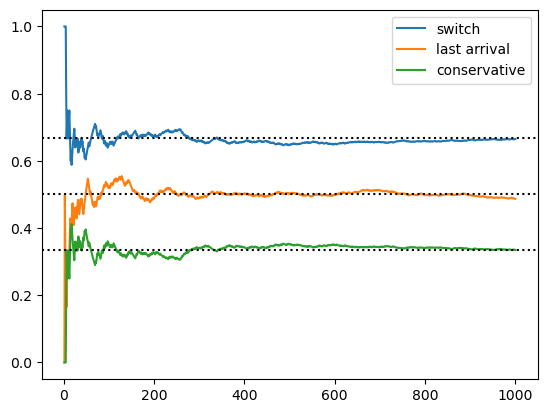

In [65]:
plt.plot(steps, probs_switch, label="switch")
plt.plot(steps, probs_last, label="last arrival")
plt.plot(steps, probs_conservative, label="conservative")

plt.axhline(1/3, ls='dotted',c='black')
plt.axhline(1/2, ls='dotted',c='black')
plt.axhline(2/3, ls='dotted',c='black')
#plt.ylim(0.2, 0.8)
plt.legend()

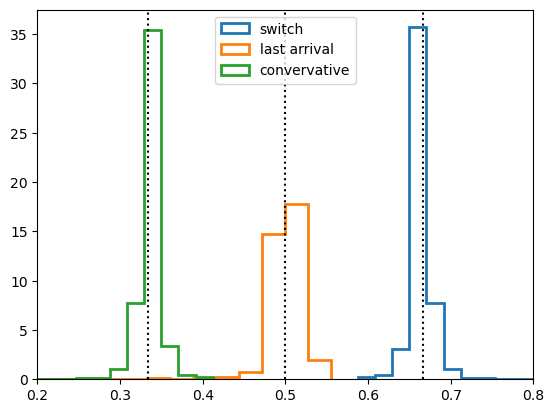

In [77]:
plt.hist(probs_switch,density=True, bins=20, histtype='step', lw=2, label="switch")
plt.hist(probs_last,density=True, histtype='step', bins=20, lw =2, label="last arrival")
plt.hist(probs_conservative,density=True, histtype='step', bins=20, lw=2, label="convervative")
plt.xlim(0.2, 0.8)
plt.axvline(1/3, ls='dotted',c='black')
plt.axvline(1/2, ls='dotted',c='black')
plt.axvline(2/3, ls='dotted',c='black')
plt.legend()

## generalizzazione caso a N porte

In [25]:
n = 14 # numero di porte 
n_sim = 10000  # numero di simulazioni
p = 5 #numero di porte aperte da mounty

#numero dei contatori
n_switch = 0
n_conservative = 0
n_last_arrival = 0 


if (p < n-2): 
    for i in range(n_sim): 
        doors = np.array(["g"] * n)
        index = np.arange(n)
        c_index = np.random.choice(index) #indice della macchina 
        doors[c_index] = "c" # "rinomino" con c indice scelto 
        choosen_door_index = np.random.choice(index)
        mask_not_choosen_index = (index != choosen_door_index)
    
        # porte che Monty può aprire (quelle con le capre) 
        g_doors_index = []
        for j in index:
            if j != choosen_door_index and doors[j] == "g":
                g_doors_index.append(j)
    
        # Monty apre p porte 
        monty_opens_index = []
        if g_doors_index: #significa che è definita 
            monty_opens_index = random.sample(g_doors_index, p)

        switch_choice_index = None
        last_arrival_choise_index = None

        remain_door_index_last_arrival = np.setdiff1d(index, monty_opens_index) #può scegliere anche quella scelta da altro giocatore
        remain_door_index_switch = np.setdiff1d(index[mask_not_choosen_index], monty_opens_index)
    
        last_arrival_choise_index = np.random.choice(remain_door_index_last_arrival)
        switch_choice_index = np.random.choice(remain_door_index_switch)
    

        if doors[switch_choice_index] == "c":
            n_switch += 1
    
        if doors[last_arrival_choise_index] == "c":
            n_last_arrival += 1

        if doors[choosen_door_index] == "c":
            n_conservative += 1
else:
    print("insert another number please!!")

# probabilità stimate
p_switch = n_switch / n_sim
p_last_arrival = n_last_arrival / n_sim
p_conservative = n_conservative / n_sim

print("Probabilità vincita cambiando porta:", p_switch)
print("Probabilità ultimo arrivato:", p_last_arrival)
print("Probabilità vincita restando:", p_conservative)

Probabilità vincita cambiando porta: 0.1166
Probabilità ultimo arrivato: 0.1102
Probabilità vincita restando: 0.0659


In [27]:
predicted_p_switch = (1/n)*(n-1)/(n-p-1)
print("predicted switch:") 
print(predicted_p_switch)
print("predicted conservative:")
print(1/n)
print("predicted last arrival:") 
print(1/(n-p))

predicted switch:
0.11607142857142856
predicted conservative:
0.07142857142857142
predicted last arrival:
0.1111111111111111
